In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors
from matplotlib import rc
import matplotlib.patches as mpatches
from Tools.Utils import calculate_mouse_centers, calculate_mouse_distance

def load_task1_data(data_path):
  """
  Load data for task 1:
      The vocaubulary tells you how to map behavior names to class ids;
      it is the same for all sequences in this dataset.
  """
  data_dict = np.load(data_path, allow_pickle=True).item()
  dataset = data_dict['annotator-id_0']
  # Get any sequence key.
  sequence_id = list(data_dict['annotator-id_0'].keys())[0]
  vocabulary = data_dict['annotator-id_0'][sequence_id]['metadata']['vocab']
  return dataset, vocabulary

# training_data, vocab = load_task1_data('./Caltech/calms21_task1_train.npy')
training_data, vocab = load_task1_data('./Caltech/calms21_task1_train_distance_lt_330.npy')
test_data, _ = load_task1_data('./Caltech/calms21_task1_test.npy')


# Helper functions for visualization

rc('animation', html='jshtml')

# Note: Image processing may be slow if too many frames are animated.

# Plotting constants
FRAME_WIDTH_TOP = 1024
FRAME_HEIGHT_TOP = 570

RESIDENT_COLOR = 'lawngreen'
INTRUDER_COLOR = 'skyblue'

PLOT_MOUSE_START_END = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4),
                        (3, 5), (4, 6), (5, 6), (1, 2)]
class_to_color = {'other': 'white', 'attack' : 'red', 'mount' : 'green',
                  'investigation': 'orange'}
class_to_number = {s: i for i, s in enumerate(vocab)}
number_to_class = {i: s for i, s in enumerate(vocab)}


def num_to_text(anno_list):
  return np.vectorize(number_to_class.get)(anno_list)


def set_figax():
  fig = plt.figure(figsize=(6, 4))

  img = np.zeros((FRAME_HEIGHT_TOP, FRAME_WIDTH_TOP, 3))

  ax = fig.add_subplot(111)
  ax.imshow(img)

  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  return fig, ax


def plot_mouse(ax, pose, color):
  # Draw each keypoint
  for j in range(7):
    ax.plot(pose[j, 0], pose[j, 1], 'o', color=color, markersize=5)

  # Draw a line for each point pair to form the shape of the mouse

  for pair in PLOT_MOUSE_START_END:
    line_to_plot = pose[pair, :]
    ax.plot(line_to_plot[:, 0], line_to_plot[
            :, 1], color=color, linewidth=1)

  # Draw the center point averaged over all keypoints
  center = np.nanmean(pose, axis=0)
  ax.plot(center[0], center[1], marker='X', color=color,
          markeredgecolor='white', markeredgewidth=1.5,
          markersize=9, zorder=4)


def animate_pose_sequence(video_name, keypoint_sequence, start_frame = 0, stop_frame = 100,
                          annotation_sequence = None, mse_sequence = None):
  # Returns the animation of the keypoint sequence between start frame
  # and stop frame. Optionally can display annotations.
  seq = keypoint_sequence.transpose((0,1,3,2))
  center_sequence = calculate_mouse_centers(keypoint_sequence)
  distance_sequence = calculate_mouse_distance(keypoint_sequence)

  image_list = []

  counter = 0
  for j in range(start_frame, stop_frame):
    if counter%20 == 0:
      print("Processing frame ", j)
    fig, ax = set_figax()
    plot_mouse(ax, seq[j, 0, :, :], color=RESIDENT_COLOR)
    plot_mouse(ax, seq[j, 1, :, :], color=INTRUDER_COLOR)

    centers = center_sequence[j]
    ax.plot(centers[:, 0], centers[:, 1], color='white', linestyle='--',
            linewidth=1.5, alpha=0.9, zorder=2)
    plt.text(50, 20, 'distance: {:.1f} px'.format(distance_sequence[j]),
             fontsize=12, color='white',
             bbox=dict(facecolor='black', edgecolor='white', alpha=0.6))

    if annotation_sequence is not None:
      annot = annotation_sequence[j]
      annot = number_to_class[annot]
      plt.text(50, -20, annot, fontsize=16,
               bbox=dict(facecolor=class_to_color[annot], alpha=0.5))

    # Show per-frame MSE when rollout prediction errors are provided.
    # ???? rollout ??????????????? MSE?
    if mse_sequence is not None:
      mse_value = mse_sequence[j - start_frame]
      plt.text(50, 55, 'MSE: {:.2f}'.format(mse_value),
               fontsize=12, color='white',
               bbox=dict(facecolor='black', edgecolor='white', alpha=0.6))

    ax.set_title(
        video_name + '\n frame {:03d}.png'.format(j))

    ax.axis('off')
    fig.tight_layout(pad=0)
    ax.margins(0)

    fig.canvas.draw()
    # image_from_plot = np.frombuffer(fig.canvas.tostring_rgb(),
    #                                 dtype=np.uint8)
    # image_from_plot = image_from_plot.reshape(
    #     fig.canvas.get_width_height()[::-1] + (3,))
    image_from_plot = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]

    image_list.append(image_from_plot)

    plt.close()
    counter = counter + 1

  # Plot animation.
  fig = plt.figure()
  plt.axis('off')
  im = plt.imshow(image_list[0])

  def animate(k):
      im.set_array(image_list[k])
      return im,
  ani = animation.FuncAnimation(fig, animate, frames=len(image_list), blit=True)
  # Close the static Matplotlib figure so Jupyter only displays the animation.
  # ???? Matplotlib ????? Jupyter ????????
  plt.close(fig)
  return ani


def plot_behavior_raster(annotation_sequence, start_frame=0,
                         stop_frame=100,
                         title="Behavior Labels"):
  # Plot annotations as a behavior raster

  # Map annotations to a number.
  annotation_num = []
  for item in annotation_sequence[start_frame:stop_frame]:
    annotation_num.append(class_to_number[item])

  all_classes = list(set(annotation_sequence[start_frame:stop_frame]))

  cmap = colors.ListedColormap(['red', 'orange', 'green', 'white'])
  bounds=[-0.5, 0.5, 1.5, 2.5, 3.5]
  norm = colors.BoundaryNorm(bounds, cmap.N)

  height = 200
  arr_to_plot = np.repeat(np.array(annotation_num)[:, np.newaxis].transpose(),
                                                  height, axis = 0)

  fig, ax = plt.subplots(figsize = (16, 3))
  ax.imshow(arr_to_plot, interpolation='none',cmap=cmap, norm=norm)

  ax.set_yticks([])
  ax.set_xlabel('Frame Number')
  plt.title(title)

  legend_patches = []
  for item in all_classes:
    legend_patches.append(mpatches.Patch(color=class_to_color[item], label=item))

  plt.legend(handles=legend_patches,loc='center left', bbox_to_anchor=(1, 0.5))

  plt.tight_layout()

rollout_path: Model/asymmetric_pose_case/runs/20260711_090246_baseline_lstm_10epochs/fold_01/rollouts/mouse003_start100_len20.npz
sequence_id: task1/train/mouse003_task1_annotator1
target frames: 100 to 119
keypoints_pred_pair shape: (20, 2, 2, 7)


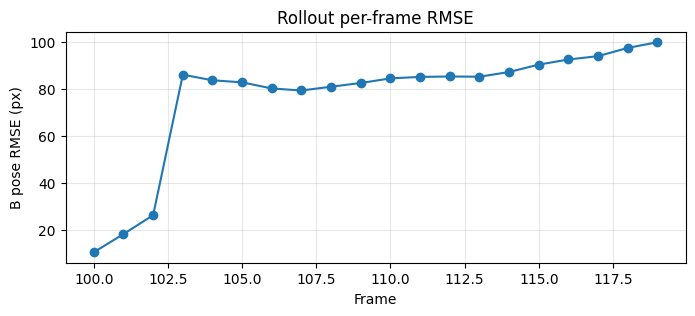

Processing frame  0


Processing frame  0


In [ ]:
# Visualize rollout prediction results produced by validation/rollout.py
# ??? validation/rollout.py ?????????
from pathlib import Path
from IPython.display import display, HTML


# "Model/asymmetric_pose_case/runs/20260711_090246_baseline_lstm_10epochs/"
# "fold_01/rollouts/mouse003_start100_len20.npz"
rollout_path = Path(
    "Model/asymmetric_pose_case/runs/20260711_090246_baseline_lstm_10epochs/"
    "fold_01/rollouts/mouse003_start100_len20.npz"
)

rollout = np.load(rollout_path, allow_pickle=True)

# keypoints_pred_pair follows the CalMS21 format: [frame, mouse, coord, joint].
# keypoints_pred_pair ?? CalMS21 ?????[?, ??, ??, ??]?
keypoints_pred_pair = rollout["keypoints_pred_pair"]
a_pose_xy = rollout["a_pose_xy"]
b_true_pose_xy = rollout["b_true_pose_xy"]
per_frame_rmse = rollout["per_frame_rmse"]
per_frame_mse = rollout["per_frame_mse"]
target_t = rollout["target_t"]
sequence_id = str(rollout["sequence_id"])
rollout_length = int(rollout["rollout_length"])

print("rollout_path:", rollout_path)
print("sequence_id:", sequence_id)
print("target frames:", target_t[0], "to", target_t[-1])
print("keypoints_pred_pair shape:", keypoints_pred_pair.shape)

# Build the true comparison pair in the same CalMS21 format.
# ?????????????? CalMS21 ???
def build_pair_keypoints(a_pose_xy, b_pose_xy):
    pair = np.empty((a_pose_xy.shape[0], 2, 2, 7), dtype=np.float32)
    pair[:, 0] = np.transpose(a_pose_xy, (0, 2, 1))
    pair[:, 1] = np.transpose(b_pose_xy, (0, 2, 1))
    return pair

keypoints_true_pair = build_pair_keypoints(a_pose_xy, b_true_pose_xy)

# Load the real annotations for the rollout frames.
# ?? rollout ???????? annotation????????
rollout_dataset, rollout_vocab = load_task1_data("./Caltech/calms21_task1_train_distance_lt_330.npy")
annotation_sequence = rollout_dataset[sequence_id]["annotations"][target_t]

# Plot per-frame rollout RMSE before the animations.
# ??????????? RMSE?????????? rollout ???
plt.figure(figsize=(8, 3))
plt.plot(target_t, per_frame_rmse, marker="o")
plt.xlabel("Frame")
plt.ylabel("B pose RMSE (px)")
plt.title("Rollout per-frame RMSE")
plt.grid(alpha=0.3)
plt.show()

# Animation 1: true A + predicted B. This is the main visualization output.
# ?? 1??? A + ?? B???????????
ani_pred = animate_pose_sequence(
    "Rollout prediction: true A + predicted B",
    keypoints_pred_pair,
    start_frame=0,
    stop_frame=rollout_length,
    annotation_sequence=annotation_sequence,
    mse_sequence=per_frame_mse,
)
# ani_pred
display(HTML(ani_pred.to_jshtml()))

# Animation 2: true A + true B, for side-by-side qualitative comparison.
# ?? 2??? A + ?? B??????????????
ani_true = animate_pose_sequence(
    "Ground truth: true A + true B",
    keypoints_true_pair,
    start_frame=0,
    stop_frame=rollout_length,
    annotation_sequence=annotation_sequence,
)
# ani_true
display(HTML(ani_true.to_jshtml()))
